
--- BASIC STATS ---
Total Messages: 472

Messages per Person:
 Name
Hakeem            237
Rubhini_DCTeam    235
Name: count, dtype: int64

Most Active Person: Hakeem
Least Active Person: Rubhini_DCTeam

--- MONTH WISE TREND ---
Name     Hakeem  Rubhini_DCTeam
Month                          
2025-12      22              14
2026-01      29              31
2026-02      30              31
2026-03      90              93
2026-04      66              66
Most Active Month: 2026-03

--- DAY ANALYSIS ---
Day
Monday       123
Thursday      96
Saturday      66
Friday        64
Tuesday       61
Wednesday     61
Sunday         1
Name: count, dtype: int64
Most Active Day: Monday

--- HOUR ANALYSIS ---
Name  Hakeem  Rubhini_DCTeam
Hour                        
6        NaN             5.0
7        NaN             1.0
10      12.0            18.0
11      19.0            17.0
12      36.0            30.0
13      17.0            19.0
14      11.0            10.0
15      20.0            27.0
16      30.0

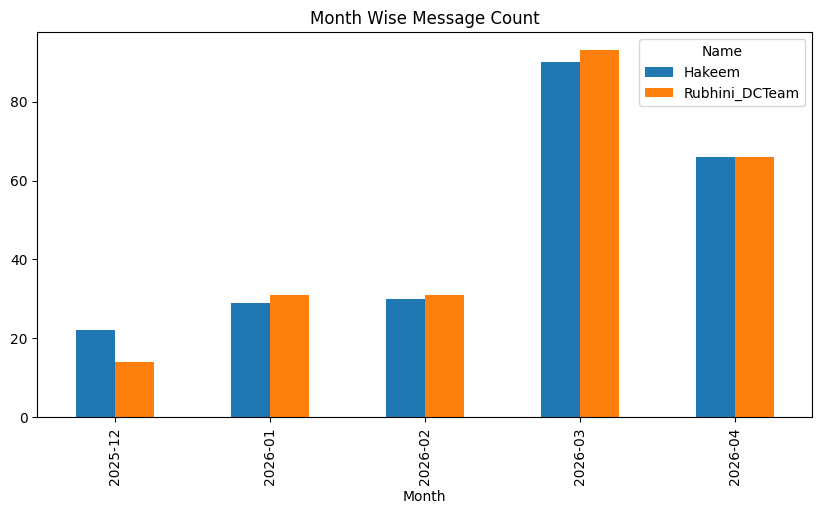

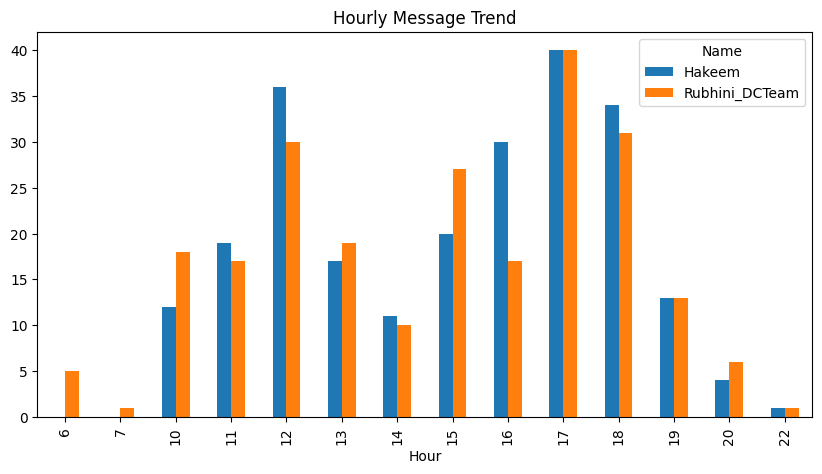

In [14]:
import re
import pandas as pd

# Read from txt file
with open("chat.txt", "r", encoding="utf-8") as file:
    chat_text = file.read()

# Regex pattern
pattern = r'(\d{1,2}/\d{1,2}/\d{4}), (\d{1,2}:\d{2}\s?[ap]m) - ([^:]+): (.*?)(?=\n\d{1,2}/\d{1,2}/\d{4},|\Z)'

matches = re.findall(pattern, chat_text, re.DOTALL)

data = []

for date, time, name, message in matches:
    
    message = message.replace('\n', ' ').strip()
    
    # Skip unwanted lines
    if "Media omitted" in message or "end-to-end encrypted" in message:
        continue

    data.append([date, time, name, message])

# Create DataFrame
df = pd.DataFrame(data, columns=["Date", "Time", "Name", "Chat"])


# Cleaning and fram creation

# Convert Date
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', dayfirst=True)
df = df.dropna(subset=['Date'])

# Create Month & Day
df['Month'] = df['Date'].dt.strftime('%Y-%m')
df['Day'] = df['Date'].dt.day_name()

# Clean Time and create Hour
df['Time'] = df['Time'].str.lower()
df['Hour'] = pd.to_datetime(df['Time'], format='%I:%M %p', errors='coerce').dt.hour
df = df.dropna(subset=['Hour'])

# ANALYSIS

print("\n--- BASIC STATS ---")
print("Total Messages:", len(df))
print("\nMessages per Person:\n", df['Name'].value_counts())

print("\nMost Active Person:", df['Name'].value_counts().idxmax())
print("Least Active Person:", df['Name'].value_counts().idxmin())

# MONTH-WISE TREND

print("\n--- MONTH WISE TREND ---")
month_trend = df.groupby(['Month', 'Name']).size().unstack()
print(month_trend)

month_trend.plot(kind='bar', figsize=(10,5), title="Month Wise Message Count")

print("Most Active Month:", df['Month'].value_counts().idxmax())

# DAY ANALYSIS

print("\n--- DAY ANALYSIS ---")
print(df['Day'].value_counts())
print("Most Active Day:", df['Day'].value_counts().idxmax())

# HOUR ANALYSIS

print("\n--- HOUR ANALYSIS ---")
hour_trend = df.groupby(['Hour', 'Name']).size().unstack()
print(hour_trend)

hour_trend.plot(kind='bar', figsize=(10,5), title="Hourly Message Trend")

print("Most Active Hour:", int(df['Hour'].value_counts().idxmax()))

# AVERAGE MESSAGES

daily_avg = df.groupby(df['Date'].dt.date).size().mean()
print("\nAverage Messages per Day:", round(daily_avg,2))

# MEDIA / CALL / DELETE

print("\n--- COMMUNICATION SUMMARY ---")

deleted_count = df['Chat'].str.contains("deleted", case=False).sum()
missed_voice = df['Chat'].str.contains("missed voice call", case=False).sum()
missed_video = df['Chat'].str.contains("missed video call", case=False).sum()

print("Deleted Message Count:", "No message was deleted" if deleted_count == 0 else deleted_count)
print("Missed Voice Call Count:", "No Missed Voice Call" if missed_voice == 0 else missed_voice)
print("Missed Video Call Count:", "No Missed Video Call" if missed_video == 0 else missed_video)

# FLIRT DETECTION (YES / NO)

flirt_keywords = ['love', 'miss you', 'dear']

def detect_flirt(text):
    text = text.lower()
    return any(word in text for word in flirt_keywords)

df['Flirt'] = df['Chat'].apply(detect_flirt)

print("\nFlirt:", "Yes" if df['Flirt'].any() else "No")

# SAVING THE OUTPUT

df.to_csv("whatsapp_output.csv", index=False)

print("\n✅ CSV created successfully")

In [16]:
# Most Active Date
most_active_date = df['Date'].dt.date.value_counts().idxmax()
print("Most Active Date:", most_active_date)

# Deleted Messages
deleted_count = df['Chat'].str.contains("deleted", case=False).sum()
print("Deleted Message Count:",
      "No message was deleted" if deleted_count == 0 else deleted_count)

# Missed Voice Calls
missed_voice = df['Chat'].str.contains("missed voice call", case=False).sum()
print("Missed Voice Call Count:",
      "No Missed Voice Call" if missed_voice == 0 else missed_voice)

Most Active Date: 2026-03-23
Deleted Message Count: 10
Missed Voice Call Count: No Missed Voice Call
